In [22]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [18]:
CSV_PATH = Path(r"C:\Users\david\Desktop\FinalData\Slice\Platform\Results\kick_pinpoint_53_landmarks.csv")

In [19]:
df = pd.read_csv(CSV_PATH)

In [9]:
df

,frame_id,NOSE_x,NOSE_y,NOSE_z,NOSE_v,LEFT_EYE_INNER_x,LEFT_EYE_INNER_y,LEFT_EYE_INNER_z,LEFT_EYE_INNER_v,LEFT_EYE_x,...,RIGHT_HEEL_z,RIGHT_HEEL_v,LEFT_FOOT_INDEX_x,LEFT_FOOT_INDEX_y,LEFT_FOOT_INDEX_z,LEFT_FOOT_INDEX_v,RIGHT_FOOT_INDEX_x,RIGHT_FOOT_INDEX_y,RIGHT_FOOT_INDEX_z,RIGHT_FOOT_INDEX_v
0,0,0.400459,0.523415,0.004724,0.999959,0.398429,0.515081,0.008869,0.999929,0.397326,...,-0.056197,0.954427,0.424473,0.823718,0.072404,0.958930,0.366214,0.851474,-0.092802,0.993202
1,1,0.400449,0.523079,0.003534,0.999956,0.398504,0.514642,0.008458,0.999921,0.397503,...,-0.053210,0.955305,0.424473,0.822835,0.089599,0.957730,0.366521,0.851664,-0.093069,0.993368
2,2,0.400269,0.522493,0.004821,0.999951,0.398456,0.514153,0.010348,0.999907,0.397468,...,-0.053070,0.956475,0.424677,0.822641,0.085660,0.957638,0.367000,0.851778,-0.094471,0.993542
3,3,0.400003,0.522445,0.003495,0.999947,0.398301,0.514152,0.009718,0.999896,0.397296,...,-0.058973,0.958542,0.424656,0.822325,0.093530,0.958208,0.367472,0.851905,-0.106250,0.993894
4,4,0.399847,0.522410,0.007178,0.999945,0.398211,0.514148,0.013293,0.999889,0.397193,...,-0.058518,0.960509,0.424687,0.822294,0.091423,0.958618,0.367820,0.851962,-0.102475,0.994154
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
664,664,0.450793,0.498679,0.062116,0.999922,0.449112,0.493593,0.052579,0.999915,0.448070,...,-0.048462,0.946793,0.450549,0.791732,-0.086911,0.941964,0.465031,0.784548,-0.062873,0.818703
665,665,0.450771,0.498225,0.062984,0.999923,0.449102,0.493279,0.053440,0.999917,0.448057,...,-0.052804,0.948094,0.450556,0.792059,-0.095562,0.941145,0.465626,0.784901,-0.067645,0.823790
666,666,0.450769,0.498210,0.065257,0.999927,0.449098,0.493275,0.055750,0.999921,0.448054,...,-0.061689,0.951091,0.450593,0.792232,-0.101022,0.942978,0.465728,0.786503,-0.076787,0.834304
667,667,0.450763,0.498212,0.065980,0.999929,0.449097,0.493284,0.056450,0.999923,0.448054,...,-0.056563,0.953121,0.450604,0.792236,-0.101126,0.944477,0.465734,0.786578,-0.067820,0.842022


*HAY VALORES NaN?*

In [20]:
# --- ANÁLISIS 1: INTEGRIDAD ---
nans = df.isna().sum().sum()
print(f"Estado del archivo: {CSV_PATH.name}")
print(f"Total Frames: {len(df)}")
print(f"Total NaNs encontrados: {nans}")
if nans == 0:
    print("✅ INTEGRIDAD PERFECTA: MediaPipe no perdió el rastro ni una vez.")
else:
    print(f"⚠️ OJO: Hay {nans} huecos que necesitarán interpolación.")

Estado del archivo: kick_pinpoint_53_landmarks.csv
Total Frames: 669
Total NaNs encontrados: 0
✅ INTEGRIDAD PERFECTA: MediaPipe no perdió el rastro ni una vez.


# --- ANÁLISIS 2: BIOMECÁNICA DEL SAQUE ---
# Vamos a pintar la altura (Eje Y) de la MUÑECA DERECHA (Right Wrist)
# y la MUÑECA IZQUIERDA (Toss arm) para ver el ritmo.

In [24]:
plt.figure(figsize=(14, 8))

<Figure size 1400x800 with 0 Axes>

<Figure size 1400x800 with 0 Axes>

# 1. TRAYECTORIA DE LA RAQUETA (Muñeca derecha - Azul)
# Invertimos 1-y porque en video el 0 está arriba y queremos ver "altura real"

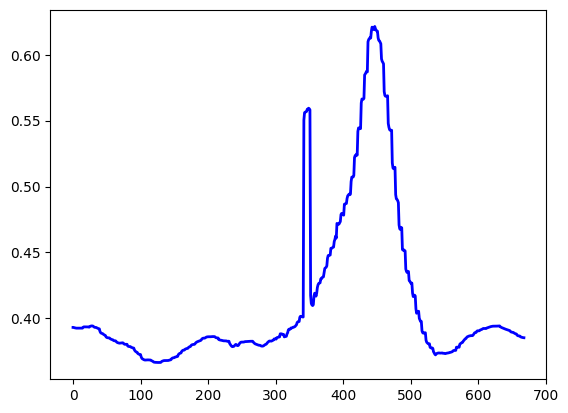

In [ ]:
plt.plot(df['frame_id'], 1 - df['RIGHT_WRIST_y'], label='Right Wrist (Raqueta)', color='blue', linewidth=2)


# 2. TRAYECTORIA DEL TOSS (Muñeca izquierda - Naranja)

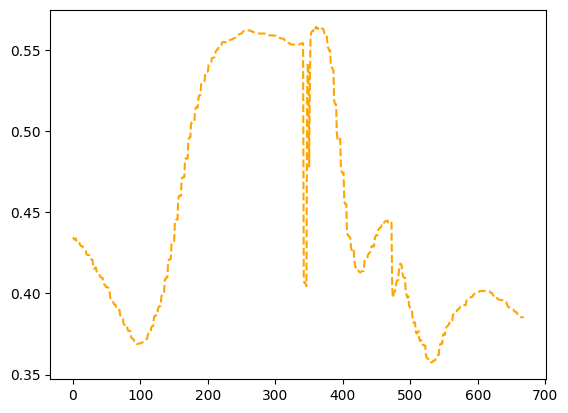

In [26]:
plt.plot(df['frame_id'], 1 - df['LEFT_WRIST_y'], label='Left Wrist (Toss)', color='orange', linestyle='--')


C:\Users\david\AppData\Local\Temp\ipykernel_14964\797106313.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


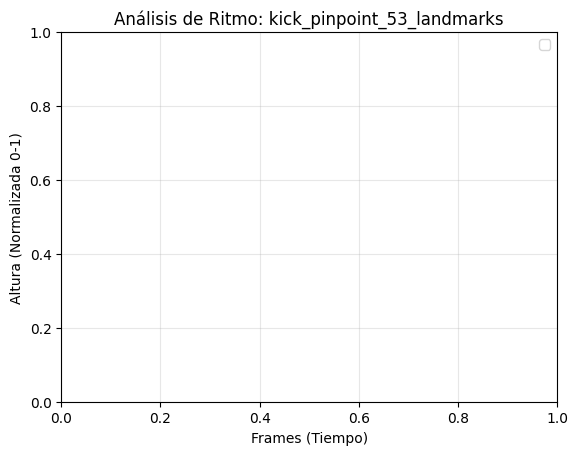

In [27]:
plt.title(f"Análisis de Ritmo: {CSV_PATH.stem}")
plt.xlabel("Frames (Tiempo)")
plt.ylabel("Altura (Normalizada 0-1)")
plt.legend()
plt.grid(True, alpha=0.3)

# Anotaciones automáticas (Buscamos el punto más alto de la raqueta = Impacto aprox)

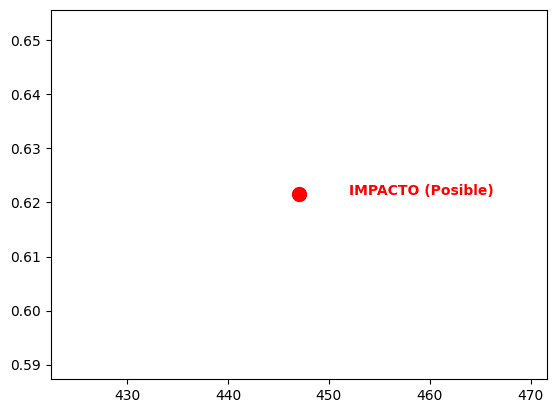

In [28]:
impact_frame = (1 - df['RIGHT_WRIST_y']).idxmax()
impact_height = (1 - df['RIGHT_WRIST_y']).max()

plt.plot(impact_frame, impact_height, 'ro', markersize=10)
plt.text(impact_frame+5, impact_height, 'IMPACTO (Posible)', color='red', fontweight='bold')

plt.show()

# --- ANÁLISIS 3: EL ZOOM AL RUIDO (JITTER) ---
# Vamos a hacer zoom en 20 frames para que veas por qué necesitas limpiar
# aunque no haya NaNs.

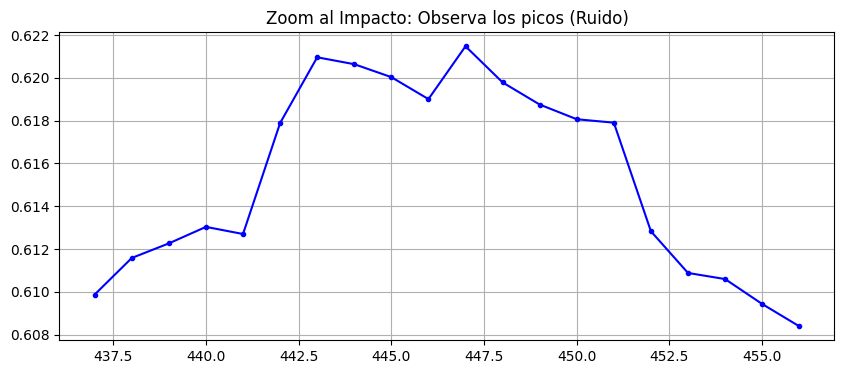

In [29]:
plt.figure(figsize=(10, 4))
subset = df.iloc[impact_frame-10 : impact_frame+10] # 20 frames alrededor del impacto
plt.plot(subset['frame_id'], 1 - subset['RIGHT_WRIST_y'], 'b.-', label='Raw Data')
plt.title("Zoom al Impacto: Observa los picos (Ruido)")
plt.grid(True)
plt.show()